In [21]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

In [8]:
iris = load_iris()

x = pd.DataFrame(iris.data, columns=iris.feature_names) #Features
y = pd.Series(iris.target, name="species")#Target

df = pd.concat([x,y],axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [40]:
x_tr,x_te,y_tr,y_te = train_test_split(x,y,test_size=0.3,stratify = y)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_tr,y_tr)
pred = model.predict(x_te)

In [41]:
print("Classification Report:\n",classification_report(y_te,pred))
print("F1-Score:",f1_score(y_te,pred,average="macro"))
print("Confusion Matrix:\n",confusion_matrix(y_te,pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.87      0.93        15
           2       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

F1-Score: 0.9553571428571429
Confusion Matrix:
 [[15  0  0]
 [ 0 13  2]
 [ 0  0 15]]


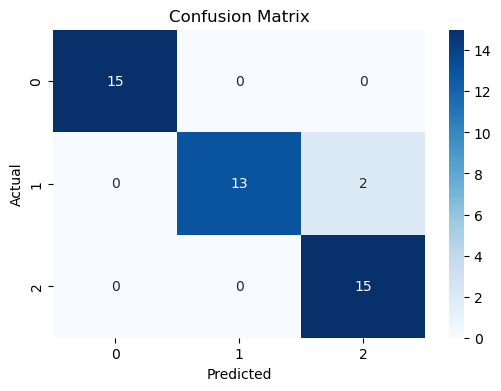

In [42]:
# Plot confusion matrix
cm = confusion_matrix(y_te,pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()